In [96]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
# Load the dataset
df = pd.read_csv("notebooks/seq_spoil.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9025 entries, 0 to 9024
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SEQ_NBR              9025 non-null   int64  
 1   SEQ_SCHD_START_DT    9025 non-null   object 
 2   FLEET                9025 non-null   int64  
 3   BASE                 9025 non-null   object 
 4   DIVISION             9025 non-null   object 
 5   SPOILAGE             9025 non-null   object 
 6   TOTAL_BLOCKED_HRS    4420 non-null   float64
 7   TOTAL_SPOILED_HRS    2719 non-null   float64
 8   SEQ_CAL_DAYS         9025 non-null   int64  
 9   SEQ_DUTY_DAYS        9025 non-null   int64  
 10  SEQ_TTL_FLTTIME      9025 non-null   int64  
 11  MIN_FLYTIME_PER_LEG  9025 non-null   int64  
 12  MAX_LEGS_PER_DAY     9025 non-null   int64  
 13  SEQ_TTL_LEGS         9025 non-null   int64  
 14  MORETHAN2_321_LEGS   9025 non-null   int64  
 15  IN_SEQ_DHD           9025 non-null   i

In [98]:
df.head(5)

,SEQ_NBR,SEQ_SCHD_START_DT,FLEET,BASE,DIVISION,SPOILAGE,TOTAL_BLOCKED_HRS,TOTAL_SPOILED_HRS,SEQ_CAL_DAYS,SEQ_DUTY_DAYS,...,MAX_LEGS_PER_DAY,SEQ_TTL_LEGS,MORETHAN2_321_LEGS,IN_SEQ_DHD,LAYOVER,SEQ_PATTERN,SEQ_START,FLIGHT_PATTERN,SEQ_START_HRS,SF_LOAD_TMS
0,4062,2025-02-06,320,CLT,I,NOT SPOILED,NaN,NaN,2,2,...,3,6,1,0,12,CLT-CUN-CLT-RDU-CLT-MCO-CLT,Starts10:25,1265-1210-1645-3026-3126-3126,10,2025-11-06 21:57:37.430
1,195,2024-04-17,777,DFW,I,NOT SPOILED,19.42,NaN,3,2,...,1,2,0,0,25,DFW-LHR-DFW,Starts15:15,50-51,15,2025-11-06 21:57:37.430
2,26551,2025-05-11,737,LAX,D,NOT SPOILED,NaN,NaN,3,3,...,2,6,0,0,15,SNA-DFW-ABQ-DFW-RNO-DFW-SNA,Starts7:45,1382-9-1035-324-1361-2465,7,2025-11-06 21:57:37.430
3,18556,2024-12-31,737,DFW,I,NOT SPOILED,NaN,NaN,1,1,...,2,2,0,0,1,DFW-NAS-DFW,Starts10:0,2585-2585,10,2025-11-06 21:57:37.430
4,20413,2024-07-06,737,MIA,I,NOT SPOILED,5.50,NaN,1,1,...,2,2,0,0,1,MIA-GUA-MIA,Starts11:11,2241-1258,11,2025-11-06 21:57:37.430


In [99]:
# Data cleaning
df.fillna(0, inplace=True)
df.drop_duplicates(inplace=True)
# Modify the dataset to calculate the estimated arrival time
df["SEQ_START_CLEAN"] = df["SEQ_START"].str.replace("Starts", "", regex=False)
df["SEQ_SCHD_START_DT"] = pd.to_datetime(df["SEQ_SCHD_START_DT"])
df["SEQ_START_DT"] = df["SEQ_SCHD_START_DT"] + pd.to_timedelta(df["SEQ_START_CLEAN"] + ":00")
df["ARRIVAL_ESTIMATE"] = (df["SEQ_START_DT"] + pd.to_timedelta(df["TOTAL_BLOCKED_HRS"], unit="h")+ pd.to_timedelta(df["LAYOVER"], unit="h"))
# Find the actual arrival time
df["FINAL_ARRIVAL"] = (df["SEQ_START_DT"] + pd.to_timedelta(df["TOTAL_BLOCKED_HRS"], unit="h")+ pd.to_timedelta(df["LAYOVER"], unit="h") + pd.to_timedelta(df["TOTAL_SPOILED_HRS"], unit="h"))


Identify where the variables for calculation live:

| Variable | Column Nmae | 
|---|---|
| Fleet code | FLEET |
| Departure | BASE |
| Takeoff time | SEQ_START_CLEAN | 
| Arrival estimate| ARRIVAL_ESTIMATE | 
| Final arrival time| FINAL_ARRIVAL |



Behavior of Flight Disruption when a Check pilot or Student pilot is assigned Grouped bar chart 
- disruption rate by pilot type

Behavior of Flight Disruption regarding  student operating experience  training    
- Line chart 
— disruption rate across training timeline

In [100]:
# Load the Assignment History dataset for pilot type
df_Assignment_History = pd.read_csv("data/raw/Assignment_History.csv")
# Unifiy the data to same case 
df_Assignment_History['CKP_ASSIGNED_IND'] = df_Assignment_History['CKP_ASSIGNED_IND'].str.upper()


/var/folders/05/nr6c3d_n40sbhlx02vwk20hc0000gn/T/ipykernel_4543/3949310471.py:2: DtypeWarning: Columns (32,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_Assignment_History = pd.read_csv("data/raw/Assignment_History.csv")


In [114]:
# Create a joined dataset for the variables above
joined_df = df.loc[:, ['FLEET', 'BASE', 'SEQ_START_CLEAN','ARRIVAL_ESTIMATE', 'FINAL_ARRIVAL','TOTAL_SPOILED_HRS', 'SEQ_NBR','SEQ_DUTY_DAYS','SEQ_CAL_DAYS','SEQ_TTL_FLTTIME','SEQ_TTL_LEGS','IN_SEQ_DHD','TOTAL_BLOCKED_HRS','LAYOVER']]


In [116]:
# create a copy of the joined_df for analysis
analysis_df = joined_df.merge(
    df_Assignment_History[['SEQ_NBR','STUDENT_ASSIGNED_IND', 'CKP_ASSIGNED_IND','IS_STUDENT_OE_STUDENT']],
    how='left',
    on='SEQ_NBR'
)
analysis_df.drop_duplicates(inplace=True)
analysis_df.dropna(inplace=True)

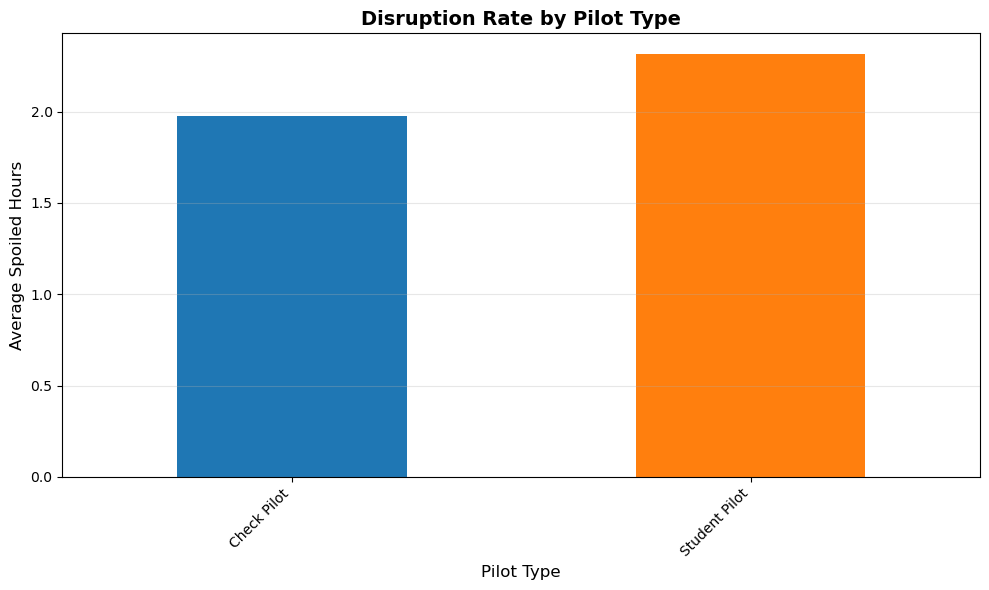

Check Pilot      1.978382
Student Pilot    2.313453
dtype: float64


In [117]:
# Disruption rate by pilot type

# Calculate average spoiled hours by pilot type
check_pilot = analysis_df[analysis_df['CKP_ASSIGNED_IND'] == 'TRUE']['TOTAL_SPOILED_HRS'].mean()
student_pilot = analysis_df[analysis_df['STUDENT_ASSIGNED_IND'] == True]['TOTAL_SPOILED_HRS'].mean()

disruption_by_pilot = pd.Series({
    'Check Pilot': check_pilot,
    'Student Pilot': student_pilot
})

# Create bar chart
plt.figure(figsize=(10, 6))
disruption_by_pilot.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Disruption Rate by Pilot Type', fontsize=14, fontweight='bold')
plt.xlabel('Pilot Type', fontsize=12)
plt.ylabel('Average Spoiled Hours', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the values
print(disruption_by_pilot)

Behavior of Flight Disruption regarding  student operating experience  training                                                                                                                  Line chart (disruption rate across training timeline)

In [118]:
# Disruption rate by student training time (end-start)
# group by student employee ID and plot the average spoiled hours by training time

# create a copy of the joined_df for analysis
student_training_df = df_Assignment_History.loc[:, ['SEQ_NBR','STUDENT_EMP_NBR','STUDENT_OE_END_DT', 'STUDENT_OE_START_DT']]
analysis_student_training_df = student_training_df.merge(
    df[['SEQ_NBR','TOTAL_SPOILED_HRS']],
    how='left',
    on='SEQ_NBR'
)

analysis_student_training_df["TRAINING_DAYS"] = (
    pd.to_datetime(analysis_student_training_df["STUDENT_OE_END_DT"]) 
    - pd.to_datetime(analysis_student_training_df["STUDENT_OE_START_DT"])
).dt.days

analysis_student_training_df.drop_duplicates(inplace=True)
analysis_student_training_df.dropna(inplace=True)    
analysis_student_training_df.head(10)




,SEQ_NBR,STUDENT_EMP_NBR,STUDENT_OE_END_DT,STUDENT_OE_START_DT,TOTAL_SPOILED_HRS,TRAINING_DAYS
11,7079,S3108,11/28/2024,11/15/2024,0.00,13.0
23,8757,S3109,11/27/2024,11/16/2024,0.00,11.0
24,8757,S3109,11/27/2024,11/16/2024,3.98,11.0
51,10000,S3096,11/23/2024,11/10/2024,0.00,13.0
60,18633,S3086,12/2/2024,11/9/2024,4.15,23.0
61,18633,S3086,12/2/2024,11/9/2024,0.00,23.0
93,18633,S3083,11/21/2024,11/16/2024,4.15,5.0
94,18633,S3083,11/21/2024,11/16/2024,0.00,5.0
225,19458,S1705,11/22/2024,11/9/2024,4.73,13.0
226,19458,S1705,11/22/2024,11/9/2024,0.00,13.0


/var/folders/05/nr6c3d_n40sbhlx02vwk20hc0000gn/T/ipykernel_4543/1784595363.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_avg = analysis_student_training_df.groupby("TRAINING_BIN")["TOTAL_SPOILED_HRS"].mean().reset_index()


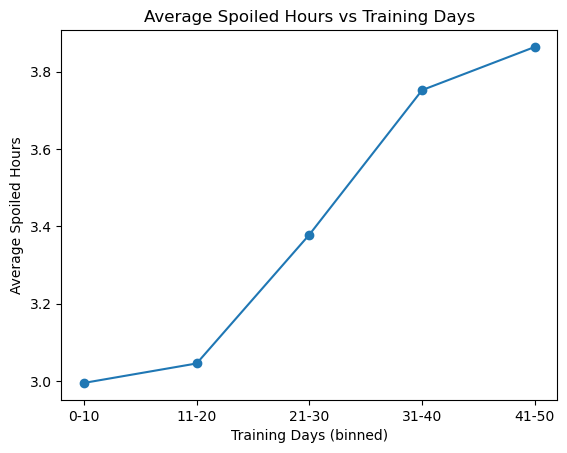

In [119]:
# 5 bins from 0 to 50
bin_edges = np.linspace(0, 50, 6)  # 6 edges = 5 bins
bin_labels = ["0-10", "11-20", "21-30", "31-40", "41-50"]

analysis_student_training_df["TRAINING_BIN"] = pd.cut(
    analysis_student_training_df["TRAINING_DAYS"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

bin_avg = analysis_student_training_df.groupby("TRAINING_BIN")["TOTAL_SPOILED_HRS"].mean().reset_index()

import matplotlib.pyplot as plt

plt.plot(bin_avg["TRAINING_BIN"], bin_avg["TOTAL_SPOILED_HRS"], marker="o")
plt.xlabel("Training Days (binned)")
plt.ylabel("Average Spoiled Hours")
plt.title("Average Spoiled Hours vs Training Days")
plt.show()



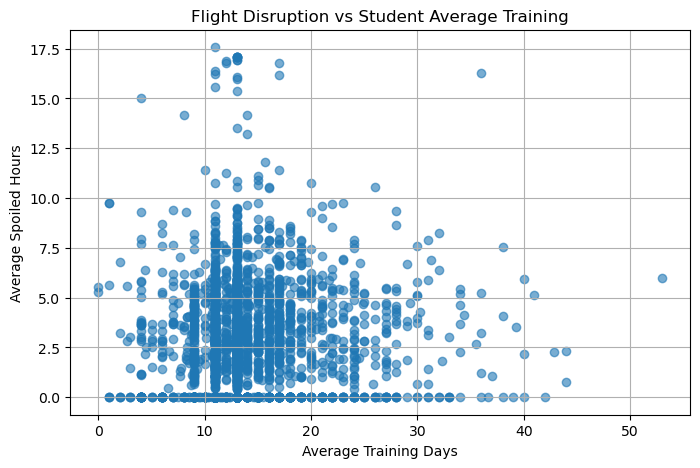

In [120]:
# Compute per-student averages scatter plot
student_avg = analysis_student_training_df.groupby("STUDENT_EMP_NBR")[["TRAINING_DAYS", "TOTAL_SPOILED_HRS"]].mean().reset_index()
student_avg.rename(columns={
    "TRAINING_DAYS": "AVG_TRAINING_DAYS",
    "TOTAL_SPOILED_HRS": "AVG_SPOILED_HRS"
}, inplace=True)


plt.figure(figsize=(8,5))
plt.scatter(student_avg["AVG_TRAINING_DAYS"], student_avg["AVG_SPOILED_HRS"], alpha=0.6)
plt.xlabel("Average Training Days")
plt.ylabel("Average Spoiled Hours")
plt.title("Flight Disruption vs Student Average Training")
plt.grid(True)
plt.show()

In [121]:
# Calculate proportion of sequences with spoiled hours 6+ spoiled hours
joined_df.head(10)

,FLEET,BASE,SEQ_START_CLEAN,ARRIVAL_ESTIMATE,FINAL_ARRIVAL,TOTAL_SPOILED_HRS,SEQ_NBR,SEQ_DUTY_DAYS,SEQ_CAL_DAYS,SEQ_TTL_FLTTIME,SEQ_TTL_LEGS,IN_SEQ_DHD,TOTAL_BLOCKED_HRS,LAYOVER
0,320,CLT,10:25,2025-02-06 22:25:00,2025-02-06 22:25:00.000000000,0.00,4062,2,2,11,6,0,0.00,12
1,777,DFW,15:15,2024-04-19 11:40:12,2024-04-19 11:40:12.000000000,0.00,195,2,3,19,2,0,19.42,25
2,737,LAX,7:45,2025-05-11 22:45:00,2025-05-11 22:45:00.000000000,0.00,26551,3,3,17,6,0,0.00,15
3,737,DFW,10:0,2024-12-31 11:00:00,2024-12-31 11:00:00.000000000,0.00,18556,1,1,7,2,0,0.00,1
4,737,MIA,11:11,2024-07-06 17:41:00,2024-07-06 17:41:00.000000000,0.00,20413,1,1,5,2,0,5.50,1
5,737,MIA,10:1,2024-10-01 10:01:00,2024-10-01 10:01:00.000000000,0.00,20182,1,1,5,2,0,0.00,0
6,320,DFW,17:15,2024-09-17 15:36:36,2024-09-17 18:50:24.000000000,3.23,5954,2,2,10,4,0,10.36,12
7,320,MIA,16:3,2025-04-10 07:03:00,2025-04-10 07:03:00.000000000,0.00,8961,2,2,10,4,0,0.00,15
8,737,MIA,9:15,2024-04-07 14:48:36,2024-04-07 20:23:23.999999999,5.58,21906,2,2,11,4,0,11.56,18
9,320,DFW,7:14,2024-11-07 07:14:00,2024-11-07 07:14:00.000000000,0.00,5897,1,1,5,2,0,0.00,0


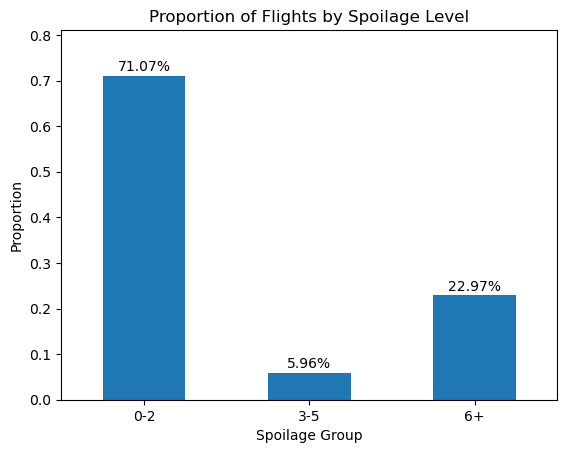

In [122]:
joined_df["SPOILAGE_GROUP"] = pd.cut(
    joined_df["TOTAL_SPOILED_HRS"],
    bins=[-0.01, 2, 5, float("inf")],
    labels=["0-2", "3-5", "6+"]
)

# Calculate proportions
proportion = joined_df["SPOILAGE_GROUP"].value_counts(normalize=True).sort_index()

# Plot bar chart
ax = proportion.plot(kind="bar")

# Add labels on top of each bar
for i, v in enumerate(proportion):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center')  # format as percentage

# Labels and title
plt.xlabel("Spoilage Group")
plt.xticks(rotation=360)
plt.ylabel("Proportion")
plt.title("Proportion of Flights by Spoilage Level")

plt.ylim(0, max(proportion) + 0.1)  # add space for labels
plt.show()

In [123]:
df_Flight_Data_With_Weather = pd.read_csv("Flight_Data_With_Weather_FINAL.csv")

In [126]:
joined_df = joined_df.merge(
    analysis_student_training_df,
    on=["SEQ_NBR","TOTAL_SPOILED_HRS"],
    how="left"
)


In [132]:
joined_df.corr(numeric_only=True)


,FLEET,TOTAL_SPOILED_HRS,SEQ_NBR,SEQ_DUTY_DAYS,SEQ_CAL_DAYS,SEQ_TTL_FLTTIME,SEQ_TTL_LEGS,IN_SEQ_DHD,TOTAL_BLOCKED_HRS,LAYOVER,TRAINING_DAYS_x,TRAINING_DAYS_y,TRAINING_DAYS
FLEET,1.000000,-0.011050,0.957693,-0.162323,-0.154059,-0.149696,0.385279,0.078318,0.057274,-0.406698,-0.007325,-0.007325,-0.007325
TOTAL_SPOILED_HRS,-0.011050,1.000000,-0.013937,0.227867,0.226470,0.231482,0.134594,0.073638,-0.018930,0.197460,0.013217,0.013217,0.013217
SEQ_NBR,0.957693,-0.013937,1.000000,-0.131762,-0.139976,-0.148718,0.379922,0.066652,0.056976,-0.368731,-0.002204,-0.002204,-0.002204
SEQ_DUTY_DAYS,-0.162323,0.227867,-0.131762,1.000000,0.993389,0.955729,0.598991,0.153732,0.156672,0.844933,0.064007,0.064007,0.064007
SEQ_CAL_DAYS,-0.154059,0.226470,-0.139976,0.993389,1.000000,0.968038,0.591736,0.157662,0.165371,0.843785,0.064375,0.064375,0.064375
SEQ_TTL_FLTTIME,-0.149696,0.231482,-0.148718,0.955729,0.968038,1.000000,0.543356,0.171173,0.176057,0.823619,0.058725,0.058725,0.058725
SEQ_TTL_LEGS,0.385279,0.134594,0.379922,0.598991,0.591736,0.543356,1.000000,0.179818,0.248084,0.166630,0.026597,0.026597,0.026597
IN_SEQ_DHD,0.078318,0.073638,0.066652,0.153732,0.157662,0.171173,0.179818,1.000000,-0.003334,0.029390,0.018905,0.018905,0.018905
TOTAL_BLOCKED_HRS,0.057274,-0.018930,0.056976,0.156672,0.165371,0.176057,0.248084,-0.003334,1.000000,0.058809,0.037885,0.037885,0.037885
LAYOVER,-0.406698,0.197460,-0.368731,0.844933,0.843785,0.823619,0.166630,0.029390,0.058809,1.000000,0.059861,0.059861,0.059861


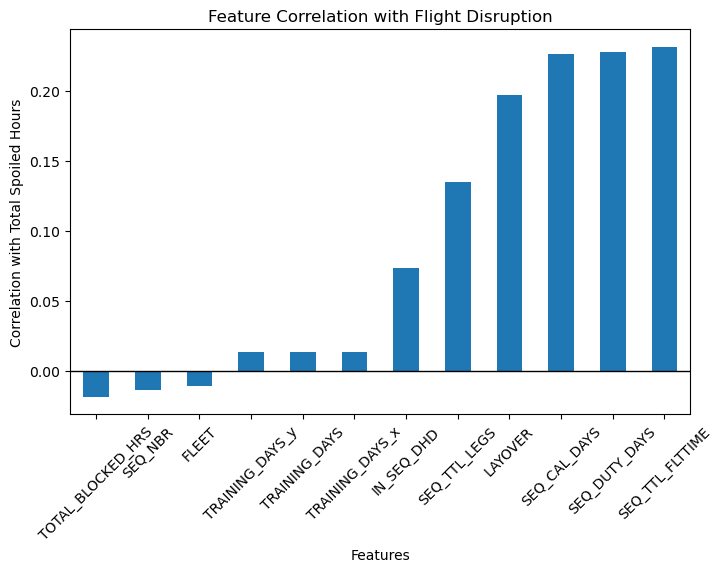

In [130]:
corr = joined_df.corr(numeric_only=True)["TOTAL_SPOILED_HRS"].sort_values()
# drop the target itself (correlation = 1)
corr = corr.drop("TOTAL_SPOILED_HRS")

plt.figure(figsize=(8,5))
corr.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Correlation with Total Spoiled Hours")
plt.title("Feature Correlation with Flight Disruption")

plt.axhline(0, color="black", linewidth=1)  # reference line at 0
plt.xticks(rotation=45)
plt.show()

In [95]:
corr.sort_values(ascending=False)

SEQ_DUTY_DAYS          0.246414
SEQ_CAL_DAYS           0.221566
SEQ_TTL_FLTTIME        0.190231
SEQ_TTL_LEGS           0.172939
IN_SEQ_DHD             0.159859
TOTAL_BLOCKED_HRS      0.154367
LAYOVER                0.147306
MAX_LEGS_PER_DAY       0.045974
MORETHAN2_321_LEGS     0.034706
FLEET                 -0.000519
SEQ_START_HRS         -0.008978
SEQ_NBR               -0.018059
MIN_FLYTIME_PER_LEG   -0.023752
Name: TOTAL_SPOILED_HRS, dtype: float64

In [ ]:
joined_df = df.loc[:, ['FLEET', 'BASE', 'SEQ_START_CLEAN','ARRIVAL_ESTIMATE', 'FINAL_ARRIVAL','TOTAL_SPOILED_HRS', 'SEQ_NBR','SEQ_DUTY_DAYS','SEQ_CAL_DAYS','SEQ_TTL_FLTTIME','SEQ_TTL_LEGS','IN_SEQ_DHD','TOTAL_BLOCKED_HRS','LAYOVER']]